# Results

Plots:
1. Discriminator AUC by dataset and model (bar)
2. AUC vs subsample fraction (line)
3. Adversarial hack convergence (lollipop)
4. Quality vs utility trade-off (scatter)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("rfhack/data/results/calibration.csv")


df["dataset"] = df["dataset"].str.replace("_", " ").str.title()

df["gmm_sigma_excess"] = df["gmm_modelhack_sigma"] - df["hack_sigma"]
df["cvae_sigma_excess"] = df["cvae_modelhack_sigma"] - df["hack_sigma"]

## Plot 1 — Did anything change?

<Figure size 800x500 with 0 Axes>

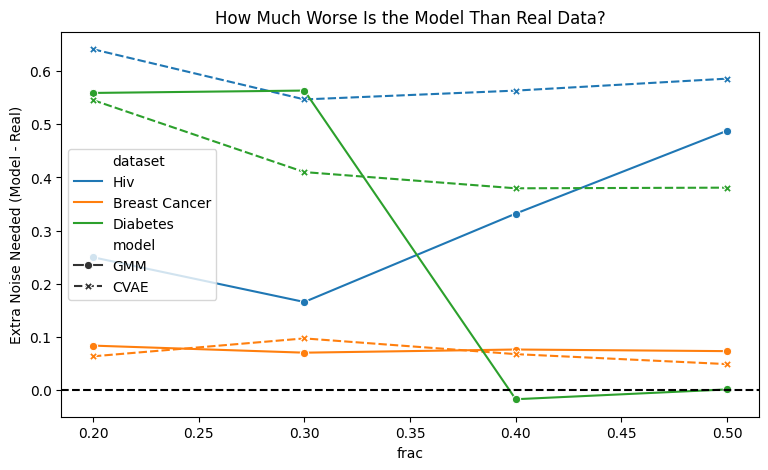

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

plot_df = pd.concat([
    df[["dataset", "frac", "gmm_sigma_excess"]].rename(columns={"gmm_sigma_excess": "sigma_excess"}).assign(model="GMM"),
    df[["dataset", "frac", "cvae_sigma_excess"]].rename(columns={"cvae_sigma_excess": "sigma_excess"}).assign(model="CVAE"),
])

plt.figure(figsize=(9,5))
sns.lineplot(
    data=plot_df,
    x="frac",
    y="sigma_excess",
    hue="dataset",
    style="model",
    markers=True
)

plt.axhline(0, linestyle="--", color="black")
plt.ylabel("Extra Noise Needed (Model - Real)")
plt.title("How Much Worse Is the Model Than Real Data?")
plt.show()

## Plot 2 — AUC vs Subsample Fraction
Does using more of the real data change how detectable synthetic data is?


1. Take the real data subset X_small
2. Run the hack on X_small itself
   -> get hack_sigma
3. Train/sample a model on X_small
   -> get X_syn
4. Run the hack on X_syn
   -> get modelhack_sigma
5. Plot the pair:
   x = hack_sigma
   y = modelhack_sigma

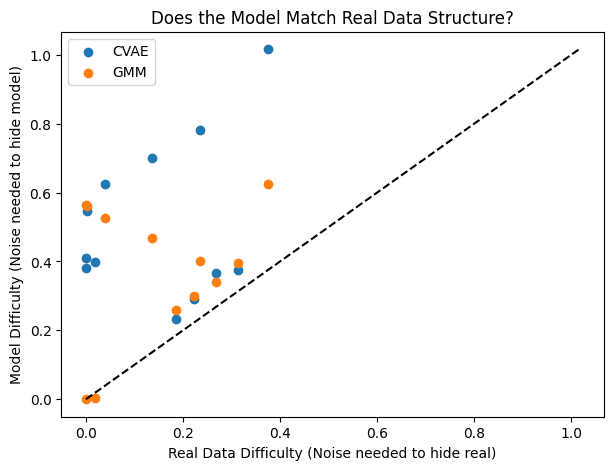

In [3]:
plt.figure(figsize=(7,5))

plt.scatter(df["hack_sigma"], df["cvae_modelhack_sigma"], label="CVAE")
plt.scatter(df["hack_sigma"], df["gmm_modelhack_sigma"], label="GMM")

# perfect line
max_val = max(df["hack_sigma"].max(), df["cvae_modelhack_sigma"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--", color="black")

plt.xlabel("Real Data Difficulty (Noise needed to hide real)")
plt.ylabel("Model Difficulty (Noise needed to hide model)")
plt.title("Does the Model Match Real Data Structure?")
plt.legend()
plt.show()

## Plot 4 — Raw vs Hacked



### CVAE

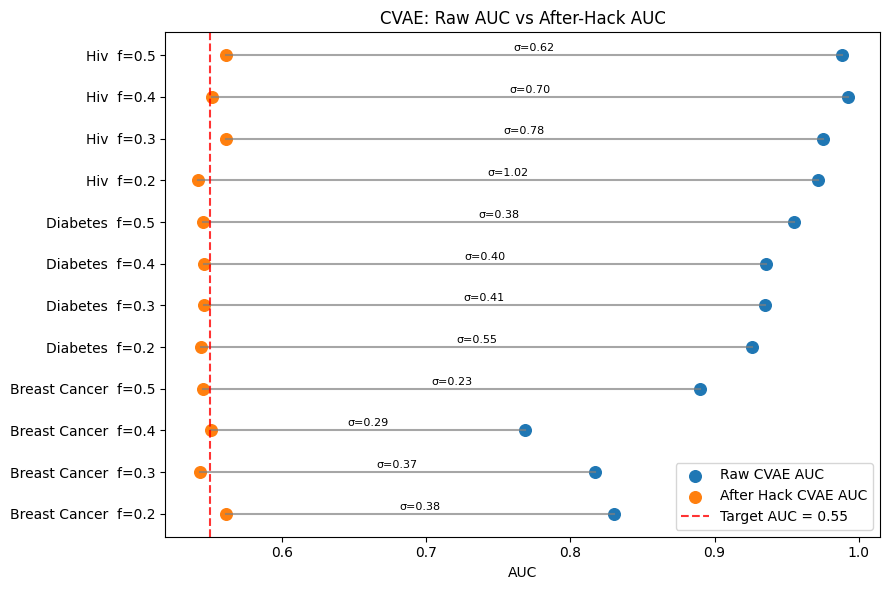

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rfhack/data/results/calibration.csv").copy()

df["dataset"] = df["dataset"].str.replace("_", " ").str.title()
df["label"] = df["dataset"] + "  f=" + df["frac"].map(lambda x: f"{x:.1f}")

sub = df.sort_values(["dataset", "frac"]).reset_index(drop=True)

y = range(len(sub))

plt.figure(figsize=(9, 6))

for i, row in sub.iterrows():
    x1 = row["cvae_auc"]
    x2 = row["cvae_modelhack_auc"]
    y_pos = i

    plt.plot([x1, x2], [y_pos, y_pos], color="gray", alpha=0.7)

    # midpoint for text
    xm = (x1 + x2) / 2

    plt.text(
        xm,
        y_pos + 0.1,
        f"σ={row['cvae_modelhack_sigma']:.2f}",
        fontsize=8,
        ha="center",
        color="black"
    )

plt.scatter(sub["cvae_auc"], y, s=70, label="Raw CVAE AUC")
plt.scatter(sub["cvae_modelhack_auc"], y, s=70, label="After Hack CVAE AUC")

plt.axvline(0.55, linestyle="--", color="red", alpha=0.8, label="Target AUC = 0.55")
plt.yticks(list(y), sub["label"])
plt.xlabel("AUC")
plt.ylabel("")
plt.title("CVAE: Raw AUC vs After-Hack AUC")
plt.legend()
plt.tight_layout()
plt.show()

### GMM

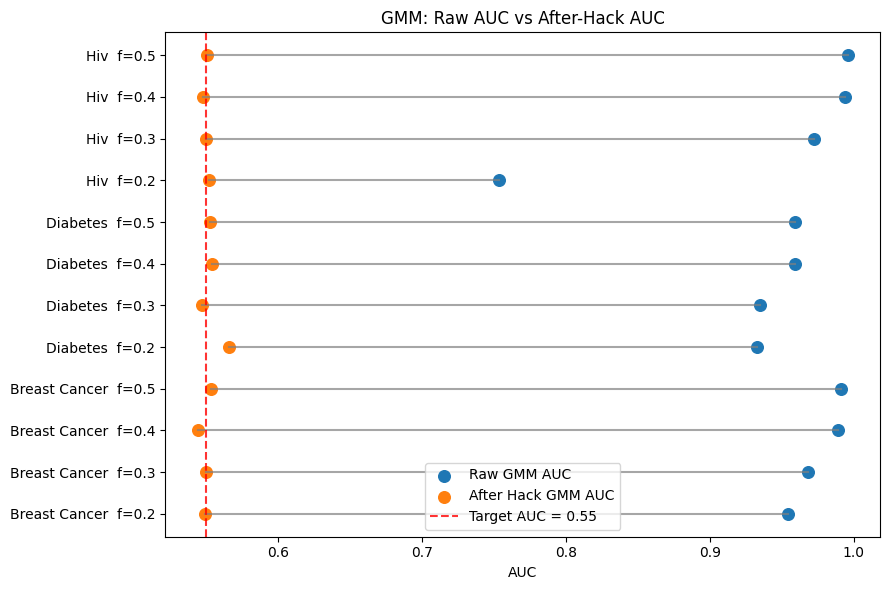

In [5]:
sub = df.sort_values(["dataset", "frac"]).reset_index(drop=True)
y = range(len(sub))

plt.figure(figsize=(9, 6))

for i, row in sub.iterrows():
    plt.plot(
        [row["gmm_auc"], row["gmm_modelhack_auc"]],
        [i, i],
        color="gray",
        alpha=0.7
    )

plt.scatter(sub["gmm_auc"], y, s=70, label="Raw GMM AUC")
plt.scatter(sub["gmm_modelhack_auc"], y, s=70, label="After Hack GMM AUC")

plt.axvline(0.55, linestyle="--", color="red", alpha=0.8, label="Target AUC = 0.55")
plt.yticks(list(y), sub["label"])
plt.xlabel("AUC")
plt.ylabel("")
plt.title("GMM: Raw AUC vs After-Hack AUC")
plt.legend()
plt.tight_layout()
plt.show()